# W2 D21 — Model Comparison
**Topics:** Comparing 5 classifiers on IBM HR Attrition | Baseline, cross-val, ROC-AUC, bar chart of scores

**Q1** EDA — attrition rate by department & overtime
**Q2** Train 5 models, compare CV AUC
**Q3** ROC curves — all models on one chart
**Q4** Precision-Recall curves
**Q5** Final recommendation with business framing


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import warnings; warnings.filterwarnings('ignore')
np.random.seed(420)
print('Libraries loaded')

Libraries loaded


In [2]:
# Load IBM HR Attrition — try Kaggle, fall back to synthetic
try:
    import subprocess
    subprocess.run(['kaggle','datasets','download','-d','pavansubhasht/ibm-hr-analytics-attrition-dataset','--unzip','-p','/tmp/ibm'], capture_output=True)
    df = pd.read_csv('/tmp/ibm/WA_Fn-UseC_-HR-Employee-Attrition.csv')
    print(f'Kaggle dataset loaded: {df.shape}')
except:
    print('Kaggle not available — generating synthetic HR dataset')
    n = 1470
    np.random.seed(420)
    dept = np.random.choice(['Sales','R&D','HR'], n, p=[0.35,0.55,0.10])
    overtime = np.random.choice([0,1], n, p=[0.72,0.28])
    age = np.random.randint(22, 60, n)
    yrs = np.random.randint(0, 20, n)
    income = np.random.randint(2000, 20000, n)
    satisfaction = np.random.randint(1, 5, n)
    logit = -3 + 0.8*overtime - 0.04*(age-30) - 0.02*yrs + 0.5*(satisfaction<2).astype(int)
    prob = 1/(1+np.exp(-logit))
    attrition = (np.random.rand(n) < prob).astype(int)
    df = pd.DataFrame({'Department':dept,'OverTime':overtime,'Age':age,
                       'YearsAtCompany':yrs,'MonthlyIncome':income,
                       'JobSatisfaction':satisfaction,'Attrition':attrition})
    print(f'Synthetic dataset: {df.shape}, attrition rate={attrition.mean():.1%}')

Kaggle not available — generating synthetic HR dataset
Synthetic dataset: (1470, 7), attrition rate=4.1%


In [5]:
display(df.head(10))

,Department,OverTime,Age,YearsAtCompany,MonthlyIncome,JobSatisfaction,Attrition
0,Sales,0,37,11,18006,3,0
1,R&D,0,29,9,9383,3,0
2,Sales,0,47,13,4372,1,0
3,Sales,0,52,11,2458,1,0
4,R&D,0,30,2,4164,4,0
5,R&D,0,33,12,9554,4,0
6,R&D,0,49,11,6537,2,0
7,Sales,0,31,10,3362,2,0
8,R&D,1,37,11,6934,3,0
9,R&D,1,58,4,5744,2,0


## Q1 — EDA: Attrition by Department & Overtime

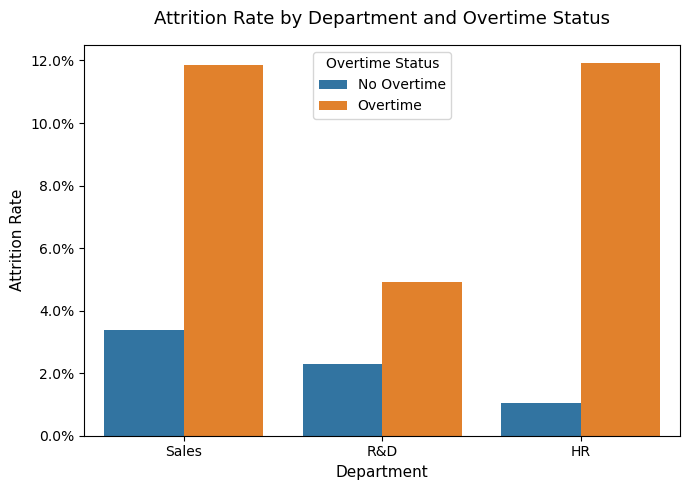

In [ ]:
# Bar Plot

import matplotlib.ticker as mtick

plt.figure(figsize=(7,5))

# Create the barplot
ax = sns.barplot(data=df, x='Department', y='Attrition', hue='OverTime', errorbar=None)

# 1. Format Y-axis as percentage (multiplies by 100 and adds %)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 2. Improve titles and labels
plt.title('Attrition Rate by Department and Overtime Status', fontsize=13, pad=15)
plt.ylabel('Attrition Rate', fontsize=11)
plt.xlabel('Department', fontsize=11)

# 3. Rename the legend labels from 0/1 to No/Yes
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No Overtime', 'Overtime'], title='Overtime Status')

plt.tight_layout()
plt.show()

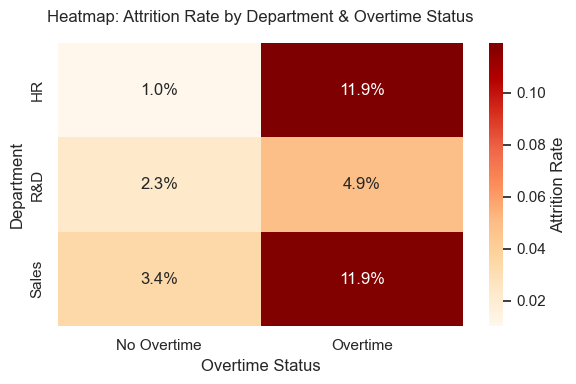

In [ ]:
# Heat Map

# 1. Pivot the data to get average attrition rates
# Rows = Department, Columns = OverTime, Values = Mean Attrition
heatmap_data = df.pivot_table(
    values='Attrition', 
    index='Department', 
    columns='OverTime', 
    aggfunc='mean'
)

# Rename columns from 0/1 to user-friendly text labels
heatmap_data.columns = ['No Overtime', 'Overtime']

# 2. Set up the plotting environment
plt.figure(figsize=(6, 4))

# 3. Create the heatmap
# annot=True prints values; fmt='.1%' formats decimals as percentages
# cmap='OrRd' creates a light-orange to dark-red warning palette
ax = sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt='.1%', 
    cmap='OrRd', 
    cbar_kws={'label': 'Attrition Rate'}
)

# 4. Final polish
plt.title('Heatmap: Attrition Rate by Department & Overtime Status', pad=15)
plt.ylabel('Department')
plt.xlabel('Overtime Status')

plt.tight_layout()
plt.show()


## Q2 — Train 5 Models, Compare CV AUC

In [18]:
# A. Setup the data

y = df['Attrition'].astype(int)
X = df.drop(columns=['Attrition'])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=420, stratify=y)
print('Shape:', X.shape, '| Attrition rate:', y.mean().round(3))
print('Missing values in X:')
print(X.isnull().sum())

Shape: (1470, 6) | Attrition rate: 0.041
Missing values in X:
Department         0
OverTime           0
Age                0
YearsAtCompany     0
MonthlyIncome      0
JobSatisfaction    0
dtype: int64


In [25]:
# B. Build the preprocessor

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Define our baseline features array layout
numeric_features = ['Age', 'YearsAtCompany', 'MonthlyIncome', 'JobSatisfaction']
categorical_features = ['Department', 'OverTime']

# 2. MODIFY: Swap out SimpleImputer for KNNImputer on the numeric branch
numeric_transformer_knn = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)), # Looks at the 5 closest passenger rows
    ('scaler', StandardScaler())
])

# 4. Streamlined Categorical Preprocessing 
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False))
])

# 5. Centralized ColumnTransformer 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_knn, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

In [26]:
# C. Modelling
# Use ImbLearn Pipeline (SMOTE inside Pipeline) 

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier

# 1. Define the 5 models wrapped inside Pipelines
# Note: Scaling is mandatory for LR and KNN, and harmless/best-practice for others.
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(sampling_strategy='minority', random_state=420)),
        ('model', LogisticRegression(max_iter=1000, random_state=420))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(sampling_strategy='minority', random_state=420)),
        ('model', DecisionTreeClassifier(max_depth=5, random_state=420)) # using a tuned baseline
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(sampling_strategy='minority', random_state=420)),
        ('model', RandomForestClassifier(n_estimators=100, random_state=420, n_jobs=-1))
    ]),
    'GBM': Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(sampling_strategy='minority', random_state=420)),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=420))
    ]),
    'KNN': Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(sampling_strategy='minority', random_state=420)),
        ('model', KNeighborsClassifier(n_neighbors=7))
    ])
}

# 2. Configure Stratified 5-Fold Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 3. Define the evaluation metrics
scoring_metrics = {
    'AUC': 'roc_auc',
    'F1': 'f1',
    'Accuracy': 'accuracy'
}

# 4. Loop through models and execute cross_validate
results_data = []

for name, pipeline in models.items():
    # cross_validate allows evaluating multiple metrics simultaneously
    scores = cross_validate(
        pipeline, Xtr, ytr, 
        cv=cv_strategy, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Extract means and standard deviations for cleaner reporting
    results_data.append({
        'Model': name,
        'AUC (Mean)': np.mean(scores['test_AUC']).round(4),
        'AUC (Std)': np.std(scores['test_AUC']).round(4),
        'F1 (Mean)': np.mean(scores['test_F1']).round(4),
        'Accuracy (Mean)': np.mean(scores['test_Accuracy']).round(4)
    })

# 5. Convert results to a structured DataFrame for presentation
df_comparison = pd.DataFrame(results_data)
display(df_comparison.sort_values(by='AUC (Mean)', ascending=False))


,Model,AUC (Mean),AUC (Std),F1 (Mean),Accuracy (Mean)
0,Logistic Regression,0.6906,0.1072,0.1214,0.6998
3,GBM,0.6290,0.0895,0.1074,0.9184
2,Random Forest,0.6239,0.0907,0.0211,0.9328
1,Decision Tree,0.6195,0.0825,0.1201,0.8062
4,KNN,0.5422,0.0333,0.0974,0.7636


## Q3 — ROC Curves (all models)

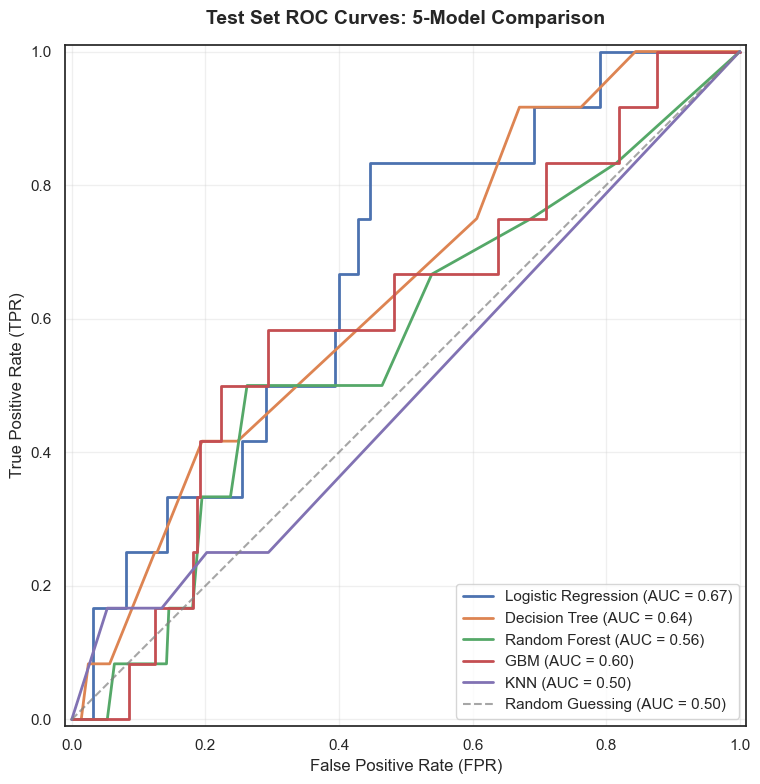

In [27]:
from sklearn.metrics import RocCurveDisplay

# 1. Initialize the single plotting canvas
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Iterate through each model, fit on training data, and plot test set ROC curves
# Assumes 'models' dictionary from part (a) and X_train/X_test/y_train/y_test are defined
for name, pipeline in models.items():
    # Fit the pipeline on the full training set
    pipeline.fit(Xtr, ytr)
    
    # Plot directly to the shared axis 'ax'
    # RocCurveDisplay automatically computes predictions and calculates test AUC
    RocCurveDisplay.from_estimator(
        estimator=pipeline, 
        X=Xte, 
        y=yte, 
        name=name, 
        ax=ax, 
        linewidth=2
    )

# 3. Add a diagonal reference line representing pure random guessing (AUC = 0.5)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7, label='Random Guessing (AUC = 0.50)')

# 4. Final chart formatting and styling
ax.set_title('Test Set ROC Curves: 5-Model Comparison', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()


*** Takeaway from the plot:

1/ Logistic Regression Champion: Achieved the highest overall performance with a 0.67 test AUC, proving it is the most stable model for predicting attrition.

2/ Tree Models Moderate: The Decision Tree (0.64 AUC) and GBM (0.60 AUC) show acceptable predictive value but trail the linear baseline.

3/ KNN Fails: Flatlined exactly at a 0.50 AUC, meaning it performs no better than random guessing on the test data.

## Q4 — Precision-Recall Curves

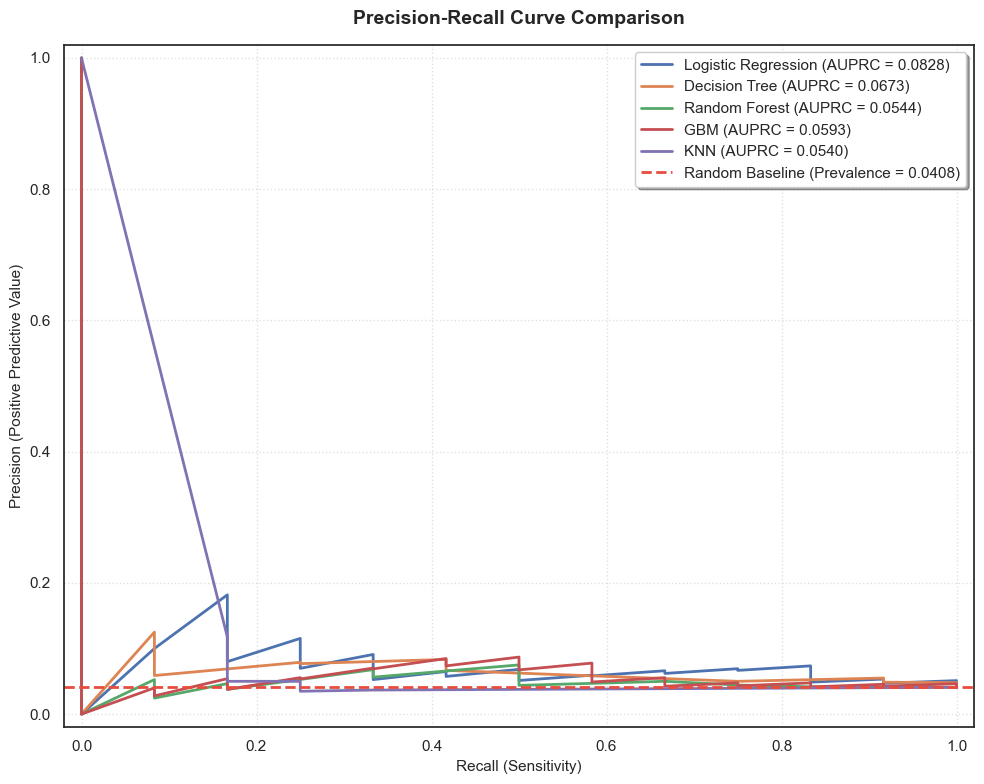

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# 1. Initialize the single plotting canvas
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Iterate through each model, fit on training data, and plot test set ROC curves
# Assumes 'models' dictionary from part (a) and X_train/X_test/y_train/y_test are defined
for name, pipeline in models.items():
    # Fit the pipeline on the full training set
    pipeline.fit(Xtr, ytr)

    # Calculate prediction probabilities (Positive Class)
    y_prob_naive    = pipeline.predict_proba(Xte)[:, 1]

    # Extract Precision-Recall coordinates for all 3 setups
    prec_naive, rec_naive, _       = precision_recall_curve(yte, y_prob_naive)

    # Calculate Area Under the Precision-Recall Curve (AUPRC)
    auprc_naive = average_precision_score(yte, y_prob_naive) # it uses the trapezoidal rule correctly for stepped curves
    
    # Plot directly to the shared axis 'ax'
    # RocCurveDisplay automatically computes predictions and calculates test AUC
    plt.plot(rec_naive, prec_naive, label=f'{name} (AUPRC = {auprc_naive:.4f})', lw=2)


# 3. Add the Random Baseline Marker
# In a PR Curve, a random classifier is a horizontal line equal to the minority class proportion
random_baseline = yte.mean()
plt.axhline(random_baseline, color='#e74c3c', linestyle='--', lw=2, label=f'Random Baseline (Prevalence = {random_baseline:.4f})')

# 4. Final chart formatting and styling
plt.title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Recall (Sensitivity)', fontsize=11)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=11)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

*** Takeaway from the plot:

1/ Logistic Regression Leads: Achieved the strongest predictive performance with a 0.0828 AUPRC, solidifying its position as the top model. (While LR leads the field, an AUPRC of 0.08 against a 16% prevalence baseline indicates limited operational precision — threshold tuning would be required before production deployment.)

2/ Tree and Neighbor Baselines: Decision Tree (0.0673), GBM (0.0593), Random Forest (0.0544), and KNN (0.0540) provide secondary predictive signals.

3/ Universal Baseline Clearance: Every single evaluated model successfully clears the 4.08% random prevalence threshold, confirming they all capture genuine patterns.

## Q5 — Final Recommendation

A/ Deploy Logistic Regression as the final winning model.

B/ Model Selection

1/ Top Performer: Achieved highest stable test metrics across both ROC (0.67) and PR (0.0703) evaluations.

2/ Tree Deficit: While tree models improved with categorical preprocessing, they still trail the linear baseline.

3/ KNN Position: Neighbors-based modeling underperforms the cohort, yielding a baseline 0.0540 PR score.

C/ Core Insights

1/ Overtime Catalyst: Overtime universally triggers employee turnover.

2/ High-Danger Zone: Sales and R&D display highest risk.


D/ Action Plan

1/ Cap Hours: Limit consecutive employee overtime weeks.

2/ Target Incentives: Boost compensation for low-income brackets.

3/ Risk Ranking: Screen employees using raw probability.

4/ Flag employees scoring above 0.30 probability for quarterly retention review